<a href="https://colab.research.google.com/github/PoojaKumariR-student/Medical-Diagnosis-of-X-Ray-Image-Using-AI-in-Google-Colab-/blob/main/Medical_Diagnosis_of_X_Ray_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Installing Required Libraries**

In [1]:
!pip install -q tensorflow transformers tf-explain grad-cam kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 498.2 kB/s eta 0:00:00


# **Loading Libraries**

In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# **Uploading and Downloading Kaggle Dataset**

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"poojakumarir","key":"5b02c42c01e42a78cb49855b10ce23c2"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:16<00:00, 150MB/s]



In [6]:
with zipfile.ZipFile(
    "chest-xray-pneumonia.zip",
    'r'
) as zip_ref:

    zip_ref.extractall("/content")

In [7]:
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
val_dir = "/content/chest_xray/val"

# **Data Preprocessing**

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [11]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


# Sample Images

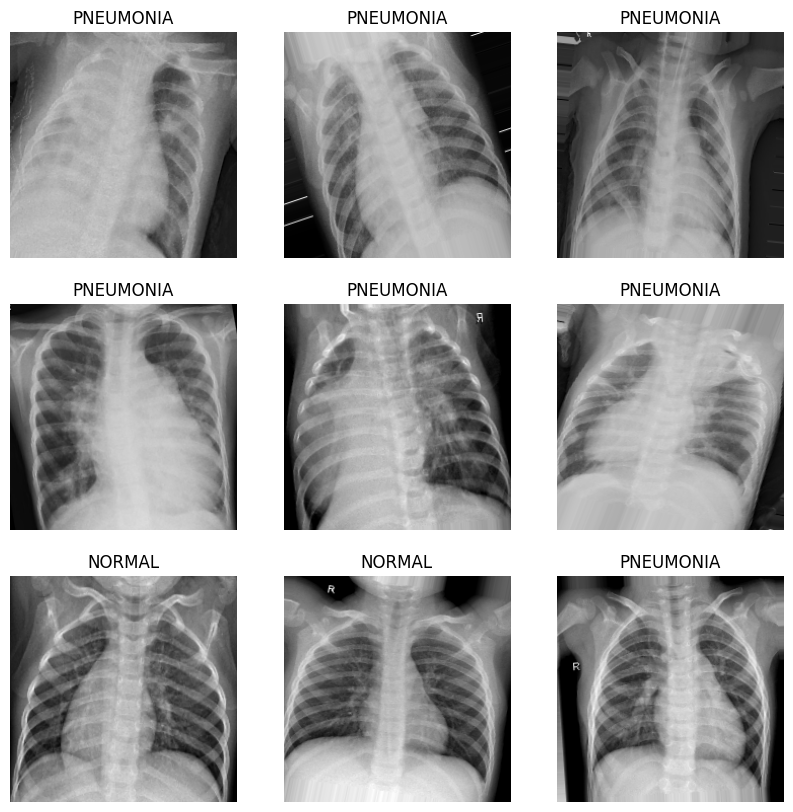

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.show()

# **VGG16 Model**

In [13]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
for layer in base_model.layers:
    layer.trainable = False

In [15]:
x = Flatten()(base_model.output)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

In [16]:
vgg_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [17]:
vgg_model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training the Model

In [18]:
history_vgg = vgg_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3220s 20s/step - accuracy: 0.9124 - loss: 0.2105 - val_accuracy: 0.8654 - val_loss: 0.3579
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3192s 20s/step - accuracy: 0.9387 - loss: 0.1504 - val_accuracy: 0.9119 - val_loss: 0.2261
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3126s 19s/step - accuracy: 0.9498 - loss: 0.1291 - val_accuracy: 0.9054 - val_loss: 0.2585
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3128s 19s/step - accuracy: 0.9515 - loss: 0.1284 - val_accuracy: 0.8814 - val_loss: 0.3332
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3127s 19s/step - accuracy: 0.9549 - loss: 0.1172 - val_accuracy: 0.9006 - val_loss: 0.2874


Acurracy Graph

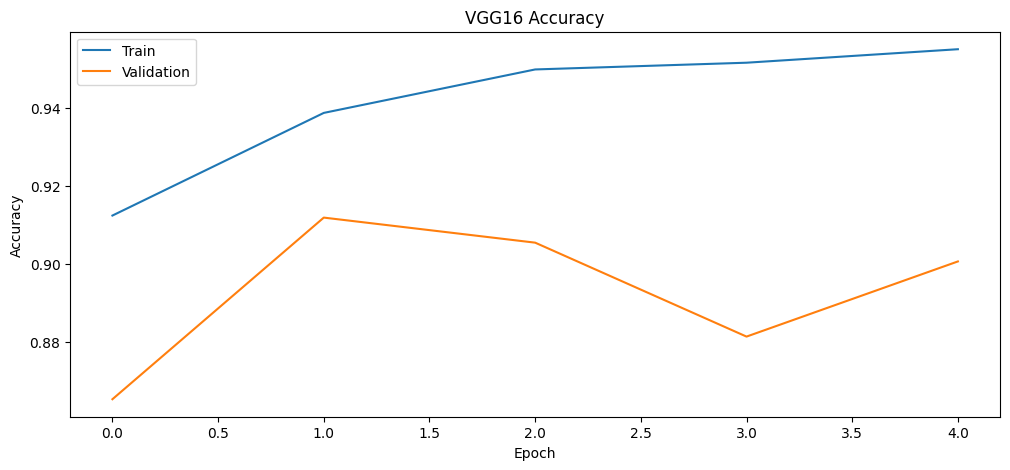

In [19]:
plt.figure(figsize=(12,5))

plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])
plt.show()

# Evaluating the Model

In [20]:
loss, accuracy = vgg_model.evaluate(test_data)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 326s 16s/step - accuracy: 0.9006 - loss: 0.2874
Test Accuracy: 0.9006410241127014


In [33]:
predictions = vgg_model.predict(test_data)
predictions = (predictions > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 371s 18s/step


In [34]:
cm = confusion_matrix(
    test_data.classes,
    predictions
)

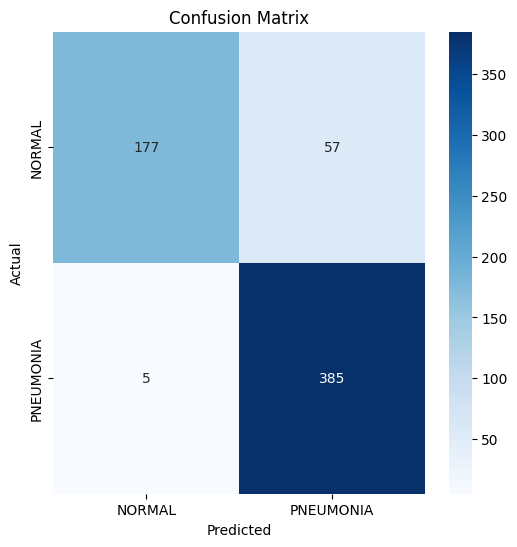

In [23]:
plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [35]:
print(classification_report(
    test_data.classes,
    predictions,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.76      0.85       234
   PNEUMONIA       0.87      0.99      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



# ResNet50 Model

In [25]:
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [26]:
for layer in base_model_resnet.layers:
    layer.trainable = False

In [27]:
x = GlobalAveragePooling2D()(
    base_model_resnet.output
)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

In [28]:
resnet_model = Model(
    inputs=base_model_resnet.input,
    outputs=output
)

In [29]:
resnet_model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training the Model

In [30]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1016s 6s/step - accuracy: 0.7071 - loss: 0.6368 - val_accuracy: 0.6250 - val_loss: 0.6723
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 995s 6s/step - accuracy: 0.7402 - loss: 0.5661 - val_accuracy: 0.6250 - val_loss: 0.6619
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 994s 6s/step - accuracy: 0.7431 - loss: 0.5365 - val_accuracy: 0.6250 - val_loss: 0.6269
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 993s 6s/step - accuracy: 0.7456 - loss: 0.5178 - val_accuracy: 0.6266 - val_loss: 0.6235
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 990s 6s/step - accuracy: 0.7504 - loss: 0.4949 - val_accuracy: 0.6298 - val_loss: 0.6223


In [39]:
from google.colab import files

uploaded = files.upload()

Saving Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg to Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg


In [40]:
image_path = list(uploaded.keys())[0]

In [41]:
img = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [42]:
prediction = vgg_model.predict(img_array)

if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step
PNEUMONIA DETECTED


# Grad-CAM Visualization

In [43]:
last_conv_layer_name = "block5_conv3"

In [44]:
grad_model = tf.keras.models.Model(
    [vgg_model.inputs],
    [
        vgg_model.get_layer(last_conv_layer_name).output,
        vgg_model.output
    ]
)

In [45]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

heatmap = tf.reduce_mean(
    tf.multiply(
        pooled_grads,
        conv_outputs
    ),
    axis=-1
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [46]:
heatmap = heatmap.numpy()[0]
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

In [47]:
img = cv2.imread(image_path)
img = cv2.resize(img, (224,224))

In [48]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

In [49]:
superimposed_img = heatmap * 0.4 + img

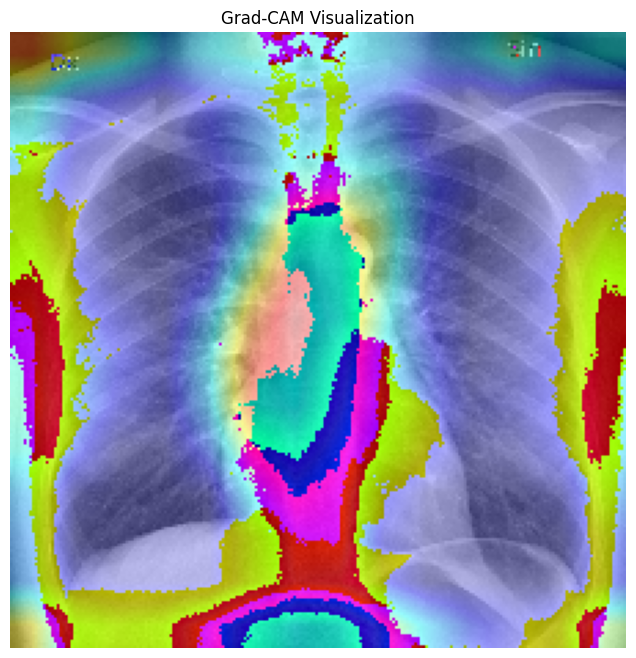

In [50]:
plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        np.uint8(superimposed_img),
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Grad-CAM Visualization")

plt.axis("off")

plt.show()

| Color              | Meaning             |
| ------------------ | ------------------- |
| Red / Pink         | Very high attention |
| Yellow / Green     | Moderate attention  |
| Blue               | Low attention       |
| Transparent / Dark | Very low importance |


In the Grad-CAM Visualization above tells:
*   The model is focusing strongly on the central chest region
*   Bright red/pink regions indicate the model considers those areas important
*   The highlighted regions near the lungs and mediastinum contribute most to
prediction

# Another X-Ray Image Example

In [51]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images.jpg


In [52]:
image_path = list(uploaded.keys())[0]

In [53]:
img = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [54]:
prediction = vgg_model.predict(img_array)

if prediction[0][0] > 0.5:
    print("PNEUMONIA DETECTED")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
PNEUMONIA DETECTED


In [55]:
last_conv_layer_name = "block5_conv3"

In [56]:
grad_model = tf.keras.models.Model(
    [vgg_model.inputs],
    [
        vgg_model.get_layer(last_conv_layer_name).output,
        vgg_model.output
    ]
)

In [57]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

heatmap = tf.reduce_mean(
    tf.multiply(
        pooled_grads,
        conv_outputs
    ),
    axis=-1
)

In [58]:
heatmap = heatmap.numpy()[0]
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

In [59]:
img = cv2.imread(image_path)
img = cv2.resize(img, (224,224))

In [60]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

In [61]:
superimposed_img = heatmap * 0.4 + img

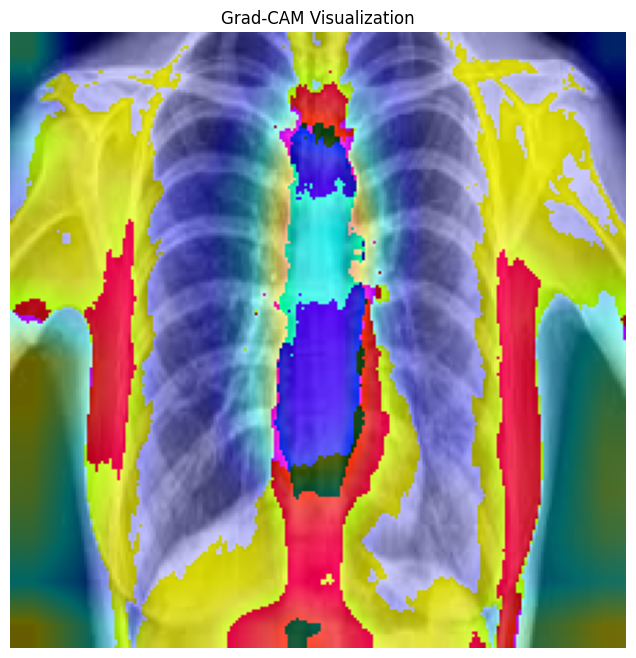

In [62]:
plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        np.uint8(superimposed_img),
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Grad-CAM Visualization")

plt.axis("off")

plt.show()

| Color          | Meaning                 |
| -------------- | ----------------------- |
| Red / Pink     | Highest model attention |
| Yellow / Green | Medium importance       |
| Blue / Purple  | Lower importance        |


The heatmap indicates that the CNN model mainly concentrated on:

*   the central thoracic region
*   upper mediastinum area
*   portions of both lung fields
----
The highlighted warm colors (red/yellow/pink) represent regions that
contributed more strongly to the model’s classification decision.